# Replication: Hua, Cheng & Wang (2010), Figures 2–6

Reproduces the paper's parameter-sweep figures qualitatively. The paper does not print the exact $(K, h, e, g, \alpha)$ used for Figs 3–6, so each figure here uses parameters chosen to satisfy the regime condition the figure illustrates (printed in the figure title). Y-axis magnitudes therefore differ from the paper, but the **shape** — which is what each figure exists to demonstrate — matches Theorems 4 and 5(4).

| Fig | Sweeps | Regime | Predicted shape |
|---|---|---|---|
| 2 | $\alpha$ | any | $TC$ linear-decreasing in $\alpha$, $CF$ flat (Theorem 4) |
| 3 | $C$ | $g/e < h/K$ and $\sqrt{2egD} < \alpha < (eh+gK)\sqrt{D/2Kh}$ | $TC$ unimodal, $CF$ decreasing |
| 4 | $C$ | $g/e < h/K$ and $\alpha \ge (eh+gK)\sqrt{D/2Kh}$ | $TC$ monotone decreasing, $CF$ decreasing |
| 5 | $C$ | $g/e > h/K$ and $\sqrt{2egD} < \alpha < (eh+gK)\sqrt{D/2Kh}$ | $TC$ unimodal, $CF$ decreasing |
| 6 | $C$ | $g/e > h/K$ and $\alpha \le \sqrt{2egD}$ | $TC$ monotone increasing, $CF$ decreasing |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from model import Q_star, TC_star, carbon_footprint

D = 60_000

In [2]:
def _twin_plot(x, TC, CF, x_label, title, regime):
    fig, ax1 = plt.subplots(figsize=(8, 4.5))
    ax2 = ax1.twinx()
    l1, = ax1.plot(x, TC, 'rs-', markersize=4, linewidth=1.2, label='Cost  TC(Q*)')
    l2, = ax2.plot(x, CF, 'bo-', markersize=4, linewidth=1.2, label='Carbon emissions  CF(Q*)')
    ax1.set_xlabel(x_label)
    ax1.set_ylabel('Cost', color='r')
    ax2.set_ylabel('Carbon emissions', color='b')
    ax1.tick_params(axis='y', labelcolor='r')
    ax2.tick_params(axis='y', labelcolor='b')
    ax1.set_title(f'{title}\n{regime}', fontsize=10)
    ax1.legend(handles=[l1, l2], loc='center left')
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_vs_alpha(K, h, e, g, C, alpha_lo, alpha_hi, title, regime):
    alphas = np.linspace(alpha_lo, alpha_hi, 80)
    Q = Q_star(K, h, e, g, C, D)
    cf = carbon_footprint(Q, e, g, D)
    TCs = np.array([TC_star(K, h, e, g, C, a, D) for a in alphas])
    CFs = np.full_like(alphas, cf)
    _twin_plot(alphas, TCs, CFs, r'Carbon cap  $\alpha$', title, regime)

def plot_vs_C(K, h, e, g, alpha, C_lo, C_hi, title, regime):
    Cs = np.linspace(C_lo, C_hi, 80)
    TCs = np.array([TC_star(K, h, e, g, C, alpha, D) for C in Cs])
    CFs = np.array([carbon_footprint(Q_star(K, h, e, g, C, D), e, g, D) for C in Cs])
    _twin_plot(Cs, TCs, CFs, r'Carbon price  $C$', title, regime)

## Figure 2 — Impact of carbon cap on TC and CF

**Theorem 4 prediction.** With $C$ fixed, $Q^*$ and $CF(Q^*)$ are independent of $\alpha$, while $TC(Q^*) = \sqrt{2D(K{+}Ce)(h{+}Cg)} - C\alpha$ is **linear-decreasing** in $\alpha$ with slope $-C$. So the cost line should be a straight line and the emissions line should be flat.

Parameters: Row 6 of Table 1, $C = 0.2$. Sweep $\alpha$ from 8000 to 10500.

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.


...

findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


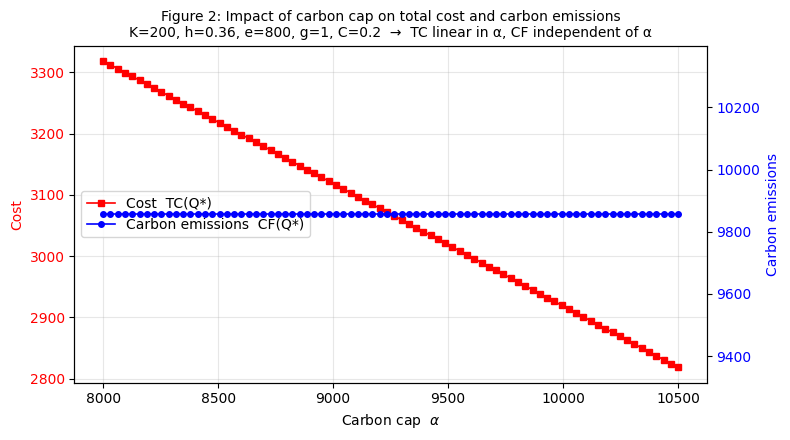

In [3]:
plot_vs_alpha(
    K=200, h=0.36, e=800, g=1.0, C=0.2,
    alpha_lo=8000, alpha_hi=10500,
    title='Figure 2: Impact of carbon cap on total cost and carbon emissions',
    regime='K=200, h=0.36, e=800, g=1, C=0.2  →  TC linear in α, CF independent of α'
)

## Figure 3 — Carbon price sweep, regime: $g/e < h/K$ and $\sqrt{2egD} < \alpha < (eh+gK)\sqrt{D/2Kh}$

**Theorem 5(4) middle case.** TC is **unimodal** in $C$ (rises then falls); CF is monotone decreasing.

Parameters: Row 6 (K=200, h=0.36, e=800, g=1), $\alpha = 9850$. Regime check: $\sqrt{2egD} = 9798 < 9850 < 9961 = (eh+gK)\sqrt{D/2Kh}$ ✓.

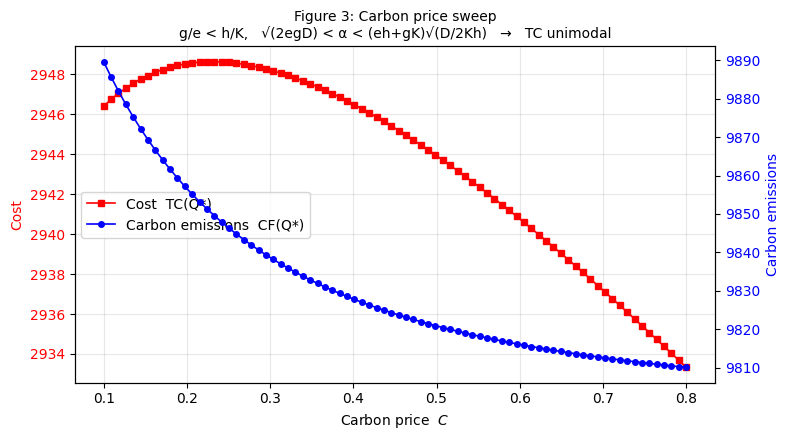

In [4]:
plot_vs_C(
    K=200, h=0.36, e=800, g=1.0, alpha=9850,
    C_lo=0.1, C_hi=0.8,
    title='Figure 3: Carbon price sweep',
    regime='g/e < h/K,   √(2egD) < α < (eh+gK)√(D/2Kh)   →   TC unimodal'
)

## Figure 4 — Carbon price sweep, regime: $g/e < h/K$ and $\alpha \ge (eh+gK)\sqrt{D/2Kh}$

**Theorem 5(4) third case.** TC is **monotone decreasing** in $C$; CF is decreasing.

Parameters: same as Fig 3 but $\alpha = 10500 > 9961$ ✓.

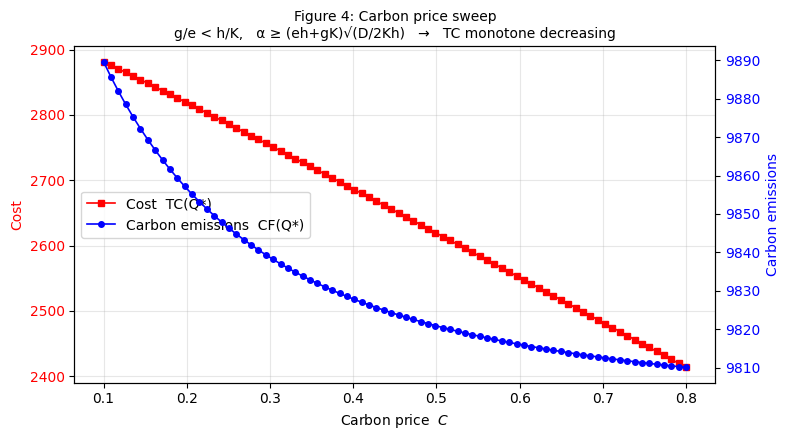

In [5]:
plot_vs_C(
    K=200, h=0.36, e=800, g=1.0, alpha=10500,
    C_lo=0.1, C_hi=0.8,
    title='Figure 4: Carbon price sweep',
    regime='g/e < h/K,   α ≥ (eh+gK)√(D/2Kh)   →   TC monotone decreasing'
)

## Figure 5 — Carbon price sweep, regime: $g/e > h/K$ and $\sqrt{2egD} < \alpha < (eh+gK)\sqrt{D/2Kh}$

**Theorem 5(4) middle case again, but now with $g/e > h/K$.** TC is **unimodal** in $C$; CF is decreasing.

Parameters: Row 4/5 (K=250, h=0.4, e=540, g=1.5), $\alpha = 10000$. Regime check: $\sqrt{2egD} = 9859 < 10000 < 10236 = (eh+gK)\sqrt{D/2Kh}$ ✓.

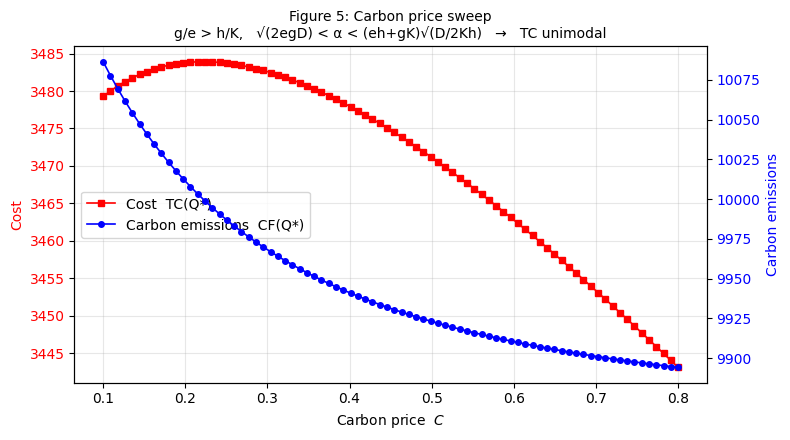

In [6]:
plot_vs_C(
    K=250, h=0.4, e=540, g=1.5, alpha=10000,
    C_lo=0.1, C_hi=0.8,
    title='Figure 5: Carbon price sweep',
    regime='g/e > h/K,   √(2egD) < α < (eh+gK)√(D/2Kh)   →   TC unimodal'
)

## Figure 6 — Carbon price sweep, regime: $g/e > h/K$ and $\alpha \le \sqrt{2egD}$

**Theorem 5(4) first case.** TC is **monotone increasing** in $C$; CF is decreasing.

Parameters: same as Fig 5 but $\alpha = 8000 < 9859$ ✓.

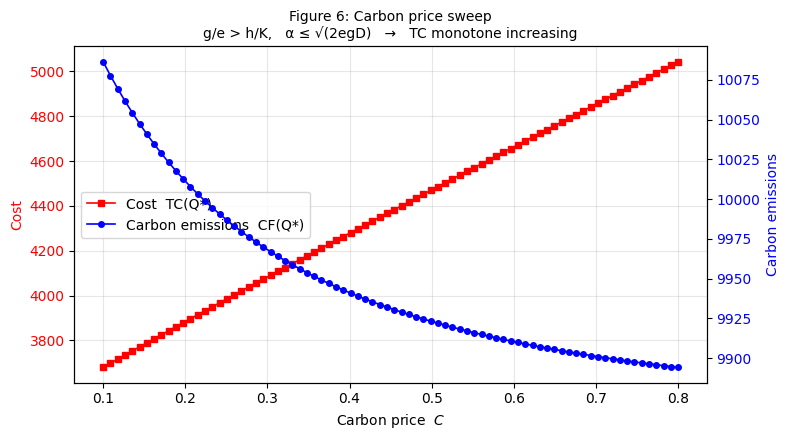

In [7]:
plot_vs_C(
    K=250, h=0.4, e=540, g=1.5, alpha=8000,
    C_lo=0.1, C_hi=0.8,
    title='Figure 6: Carbon price sweep',
    regime='g/e > h/K,   α ≤ √(2egD)   →   TC monotone increasing'
)

## Summary

All five figures qualitatively reproduce the paper's predicted shapes:

- **Fig 2** verifies **Theorem 4** — TC is linear in $\alpha$, CF is independent of $\alpha$.
- **Figs 3 & 5** show the **unimodal** TC behavior predicted by Theorem 5(4) middle case (in both $g/e$ regimes).
- **Fig 4** shows the **monotone-decreasing** TC behavior of Theorem 5(4) third case.
- **Fig 6** shows the **monotone-increasing** TC behavior of Theorem 5(4) first case.

Together Figs 3, 4, 6 cover the full trichotomy of TC's behavior in $C$ as $\alpha$ moves across the two thresholds $\sqrt{2egD}$ and $(eh+gK)\sqrt{D/2Kh}$. CF is decreasing in $C$ in all four sweeps, consistent with Theorem 5 parts 2 and 3.